# Robust modulated-coupling iSWAP — `VariationalSplinePulseProblem`

Matches the 03_andrew setup (same Hamiltonian and drive bounds) but adds variational
robustness to ZI, IZ, ZZ dephasing.  Cubic-Hermite splines give smooth, hardware-realistic pulses.


In [1]:
import Pkg
Pkg.activate(".")
# dev-install the local Piccolo.jl branch (absolute path for robustness)
piccolo_path = joinpath(@__DIR__, "..", "..", "..", "Piccolo.jl")
Pkg.develop(path=piccolo_path)
# dev-install local DirectTrajOpt.jl (fixes TimeDependentBilinearIntegrator arg order bug)
directtrajopt_path = joinpath(@__DIR__, "..", "..", "..", "DirectTrajOpt.jl")
Pkg.develop(path=directtrajopt_path)
Pkg.add(["CairoMakie", "Ipopt"])
Pkg.instantiate()

  Activating project at `~/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/robust_control_sam/src/modulate_iswap`
   Resolving package versions...
  No Changes to `~/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/robust_control_sam/src/modulate_iswap/Project.toml`
  No Changes to `~/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/robust_control_sam/src/modulate_iswap/Manifest.toml`
   Resolving package versions...
  No Changes to `~/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/robust_control_sam/src/modulate_iswap/Project.toml`
  No Changes to `~/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/robust_control_sam/src/modulate_iswap/Manifest.toml`
   Resolving package versions...
  No Changes to `~/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/robust_control_sam/src/modulate_iswap/Project.toml`
  No Changes to `~/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/robust_control_sam/src/mo

In [2]:
using Piccolo
using LinearAlgebra
using Random
using Printf
using CairoMakie


## Physical parameters and operators

Directly mirror the values from `03_andrew`: δ₁₂ = 2π×0.05 GHz, all drive bounds 2π×0.01 GHz.


In [3]:
# Detuning (rad/ns) — from 03_andrew
δ12 = 2π * 0.05

XX = operator_from_string("XX")
YY = operator_from_string("YY")
XY = operator_from_string("XY")
YX = operator_from_string("YX")
XI = operator_from_string("XI")
YI = operator_from_string("YI")
IX = operator_from_string("IX")
IY = operator_from_string("IY")
IZ = operator_from_string("IZ")
ZI = operator_from_string("ZI")
ZZ = operator_from_string("ZZ")

# iSWAP target
U_goal = exp(-im * π/4 * (XX + YY))

# Drive bounds — same as 03_andrew: 10 MHz for all 5 drives
a_bound = 2π * 0.01
drive_bounds = fill(a_bound, 5)

println("δ₁₂ = ", round(δ12/(2π), digits=4), " GHz")
println("drive bound = ", round(a_bound/(2π)*1e3, digits=1), " MHz")


δ₁₂ = 0.05 GHz
drive bound = 10.0 MHz


## Hamiltonian and VariationalQuantumSystem

Same H(u,t) as 03_andrew.  Error channels: static ZI, IZ, ZZ dephasing (not time-dependent).


In [4]:
# Non-local frame Hamiltonian: u = [g, uX1, uY1, uX2, uY2]
function H_nonlocal(u, t)
    g, uX1, uY1, uX2, uY2 = u
    return (
        δ12/2 * IZ
        + g * ((XX + YY) * cos(δ12 * t) + (YX - XY) * sin(δ12 * t))
        + uX1 * XI + uY1 * YI
        + uX2 * IX + uY2 * IY
    )
end

# Static dephasing error channels
H_vars = [
    (u, t) -> ZI,   # ZI dephasing
    (u, t) -> IZ,   # IZ dephasing
    (u, t) -> ZZ,   # ZZ correlated dephasing
]

varsys = VariationalQuantumSystem(
    H_nonlocal, H_vars, 5, drive_bounds;
    time_dependent = true
)

println("levels = ", varsys.levels, "  n_drives = ", varsys.n_drives,
        "  n_vars = ", length(varsys.G_vars), "  time_dep = ", varsys.time_dependent)


levels = 4  n_drives = 5  n_vars = 3  time_dep = true


## Build problem and solve

**Pulse parameterization**: `LinearSplinePulse` = piecewise-constant (PWC) for the dynamics.
The `TimeDependentBilinearIntegrator` evaluates `G(u_k, t_k)` once at the start of each interval,
so the actual Hamiltonian integration is constant within each step.  The `:du` and `:ddu` variables
are finite-difference consistency constraints on the NLP — they don't change the physics but give
you control over how abruptly the pulse can change:

- `du_bound`: max slope between consecutive knots → bandwidth limit
- `ddu_bound`: max change in slope between consecutive intervals → acceleration / smoothness limit

**Equal timesteps**: `PiccoloOptions(timesteps_all_equal=true)` pins all Δt to the same scalar,
which varies freely within `Δt_bounds`.


In [5]:
Random.seed!(42)
n_samples = 300
T_f       = 100.0
N_knots   = 20
Δt        = T_f / N_knots

# Dense random initialization (same style as 03_andrew): sample at n_samples knots,
# then SplinePulseProblem resamples down to N_knots NLP knots.
controls = 2 .* a_bound .* rand(5, n_samples) .- a_bound
times    = collect(LinRange(0.0, T_f, n_samples))
pulse    = LinearSplinePulse(controls, times)

qcp = VariationalSplinePulseProblem(
    varsys, pulse, U_goal, N_knots;
    Q         = 0.0,
    Q_r       = 1.0,
    R         = 1e-3,
    du_bound  = a_bound * 3,
    ddu_bound = a_bound * 2,
    Δt_bounds = (0.5Δt, 2Δt),
    piccolo_options = PiccoloOptions(
        timesteps_all_equal = true,
        verbose             = true,
    ),
)

push!(qcp.prob.constraints,
    FinalUnitaryFidelityConstraint(U_goal, :Ũ⃗, 0.9999, get_trajectory(qcp))
)

println("\nTrajectory components: ", keys(get_trajectory(qcp).components))

    constructing VariationalSplinePulseProblem...
      pulse type: LinearSplinePulse{DataInterpolations.LinearInterpolation{Matrix{Float64}, Vector{Float64}, Vector{Union{}}, Vector{Vector{Float64}}, Float64}}
      time_dependent: true
      variational directions: 3
      added augmented state :var_Ũ⃗  dim=128  (3 error channels)
      added DerivativeIntegrator (:u → :du) for LinearSplinePulse
      added DerivativeIntegrator (:du → :ddu) for acceleration bound
      applying TimeStepsAllEqualConstraint

Trajectory components: (:Ũ⃗, :Δt, :t, :u, :du, :ddu, :var_Ũ⃗)


In [6]:
let
    traj    = get_trajectory(qcp)
    us      = traj[:u]
    ts      = vec(traj[:t])
    iso_dim = traj.dims[:Ũ⃗]

    nominal_sys = QuantumSystem(H_nonlocal, drive_bounds; time_dependent=true)
    nlp_pulse   = LinearSplinePulse(us, ts)
    nlp_qtraj   = UnitaryTrajectory(nominal_sys, nlp_pulse, U_goal)

    Ũ⃗_init = hcat([operator_to_iso_vec(nlp_qtraj(t)) for t in ts]...)

    # Fix :Ũ⃗
    traj.data[traj.components[:Ũ⃗], :] .= Ũ⃗_init
    # Fix the nominal block (rows 1:iso_dim) of :var_Ũ⃗
    rows_var = traj.components[:var_Ũ⃗]
    traj.data[rows_var[1:iso_dim], :] .= Ũ⃗_init

    U_init = iso_vec_to_operator(Ũ⃗_init[:, end])
    F0 = abs2(tr(U_goal' * U_init)) / varsys.levels^2
    @printf("Initial fidelity (NLP-consistent init): %.4f\n", F0)
end

Initial fidelity (NLP-consistent init): 0.1677


In [7]:
log_path = joinpath(pwd(), "ipopt_solve.log")
rm(log_path; force = true)

solve!(qcp;
    max_iter = 500,
    options  = IpoptOptions(eval_hessian = false, output_file = log_path),
)

if isfile(log_path)
    lines = readlines(log_path)
    print(join(lines[max(1, end-30):end], "\n"))
end

    initializing optimizer...
      building evaluator: 4 integrators, 1 nonlinear constraints
      dynamics constraints: 3230, nonlinear constraints: 1
        integrator 1 jacobian structure: 0.14s
        integrator 2 jacobian structure: 0.032s
        integrator 3 jacobian structure: 0.01s
        integrator 4 jacobian structure: 0.006s
        constraint 1 (NonlinearKnotPointConstraint) jacobian structure: 0.689s
      jacobian structure: 1143432 nonzeros (0.902s)
        integrator 1 hessian structure: 0.264s
        integrator 2 hessian structure: 0.053s
        integrator 3 hessian structure: 0.258s
        integrator 4 hessian structure: 0.034s
        constraint 1 (NonlinearKnotPointConstraint) hessian structure: 3.501s
        computing objective hessian structure (CompositeObjective)...
          sub-objective 1 (KnotPointObjective): 0.141s
          sub-objective 2 (QuadraticRegularizer): 0.089s
          sub-objective 3 (QuadraticRegularizer): 0.0s
          sub-objectiv

## Default (non-robust) optimization

Mirrors the 03_andrew setup: 300 uniformly-sampled initial controls, N=100 NLP knots, Δt_bounds=(0.5, 2.0) ns. No robustness regularization — pure infidelity objective with default settings. Used as a baseline in the comparison plots.

In [17]:
# Default optimization — mirrors 03_andrew setup
Random.seed!(42)
n_samples_def = 300
N_def   = 20
Δt_def  = T_f / N_def   # 1.0 ns

# Uniform random initialization from drive bounds (03_andrew style)
controls_def = 2 .* a_bound .* rand(5, n_samples_def) .- a_bound
times_def    = collect(LinRange(0.0, T_f, n_samples_def))
pulse_def    = LinearSplinePulse(controls_def, times_def)

nominal_sys = QuantumSystem(H_nonlocal, drive_bounds; time_dependent = true)
qtraj_def   = UnitaryTrajectory(nominal_sys, pulse_def, U_goal)

qcp_def = SplinePulseProblem(
    qtraj_def, N_def;
    Δt_bounds = (0.5Δt_def, 2Δt_def),
)

log_path_def = joinpath(pwd(), "ipopt_default.log")
rm(log_path_def; force = true)

solve!(qcp_def;
    max_iter = 500,
    options  = IpoptOptions(eval_hessian = false, output_file = log_path_def),
)

if isfile(log_path_def)
    lines = readlines(log_path_def)
    print(join(lines[max(1, end-30):end], "\n"))
end

    constructing SplinePulseProblem with LinearSplinePulse{DataInterpolations.LinearInterpolation{Matrix{Float64}, Vector{Float64}, Vector{Union{}}, Vector{Vector{Float64}}, Float64}}...
	applying timesteps_all_equal constraint: Δt
    added DerivativeIntegrator for LinearSplinePulse
    initializing optimizer...
      building evaluator: 2 integrators, 0 nonlinear constraints
      dynamics constraints: 703, nonlinear constraints: 0
        integrator 1 jacobian structure: 0.001s
        integrator 2 jacobian structure: 0.008s
      jacobian structure: 61864 nonzeros (0.009s)
        integrator 1 hessian structure: 0.001s
        integrator 2 hessian structure: 0.002s
        computing objective hessian structure (CompositeObjective)...
          sub-objective 1 (KnotPointObjective): 0.0s
          sub-objective 2 (QuadraticRegularizer): 0.0s
          sub-objective 3 (QuadraticRegularizer): 0.0s
          sub-objective 4 (NullObjective): 0.0s
        objective hessian structure: 0.00

## Results


In [18]:
traj = get_trajectory(qcp)   # qcp.prob.trajectory — NLP trajectory

# Diagnostic: confirm controls are non-zero
u_data = traj[:u]
println("traj components: ", keys(traj.components))
println("u size: ", size(u_data))
println("u range: ", extrema(u_data))

U_final = iso_vec_to_operator(traj[:Ũ⃗][:, end])
fidelity = abs2(tr(U_goal' * U_final)) / size(U_goal, 1)^2
@printf("Unitary fidelity: %.6f\n", fidelity)
@printf("Infidelity:       %.2e\n", 1 - fidelity)


traj components: (:Ũ⃗, :Δt, :t, :u, :du, :ddu, :var_Ũ⃗)
u size: (5, 20)
u range: (-0.0620010745350276, 0.062123915027180704)
Unitary fidelity: 0.999916
Infidelity:       8.36e-05


In [20]:
# Variational susceptibilities at final time
error_lbls = ["ZI", "IZ", "ZZ"]
iso_dim    = traj.dims[:Ũ⃗]
n_vars     = length(error_lbls)

println("Final variational susceptibilities ||∂U(T)||²:")
for (i, lbl) in enumerate(error_lbls)
    block = traj[:var_Ũ⃗][(i*iso_dim+1):((i+1)*iso_dim), end]
    @printf("  ε(%s) = %.4e\n", lbl, sum(abs2, block))
end


Final variational susceptibilities ||∂U(T)||²:
  ε(ZI) = 8.1163e+02
  ε(IZ) = 1.7205e+03
  ε(ZZ) = 1.9285e+03


## Optimized controls


## Robust

Gate time: 95.57 ns
Δt range:  (4.7787, 4.7787)


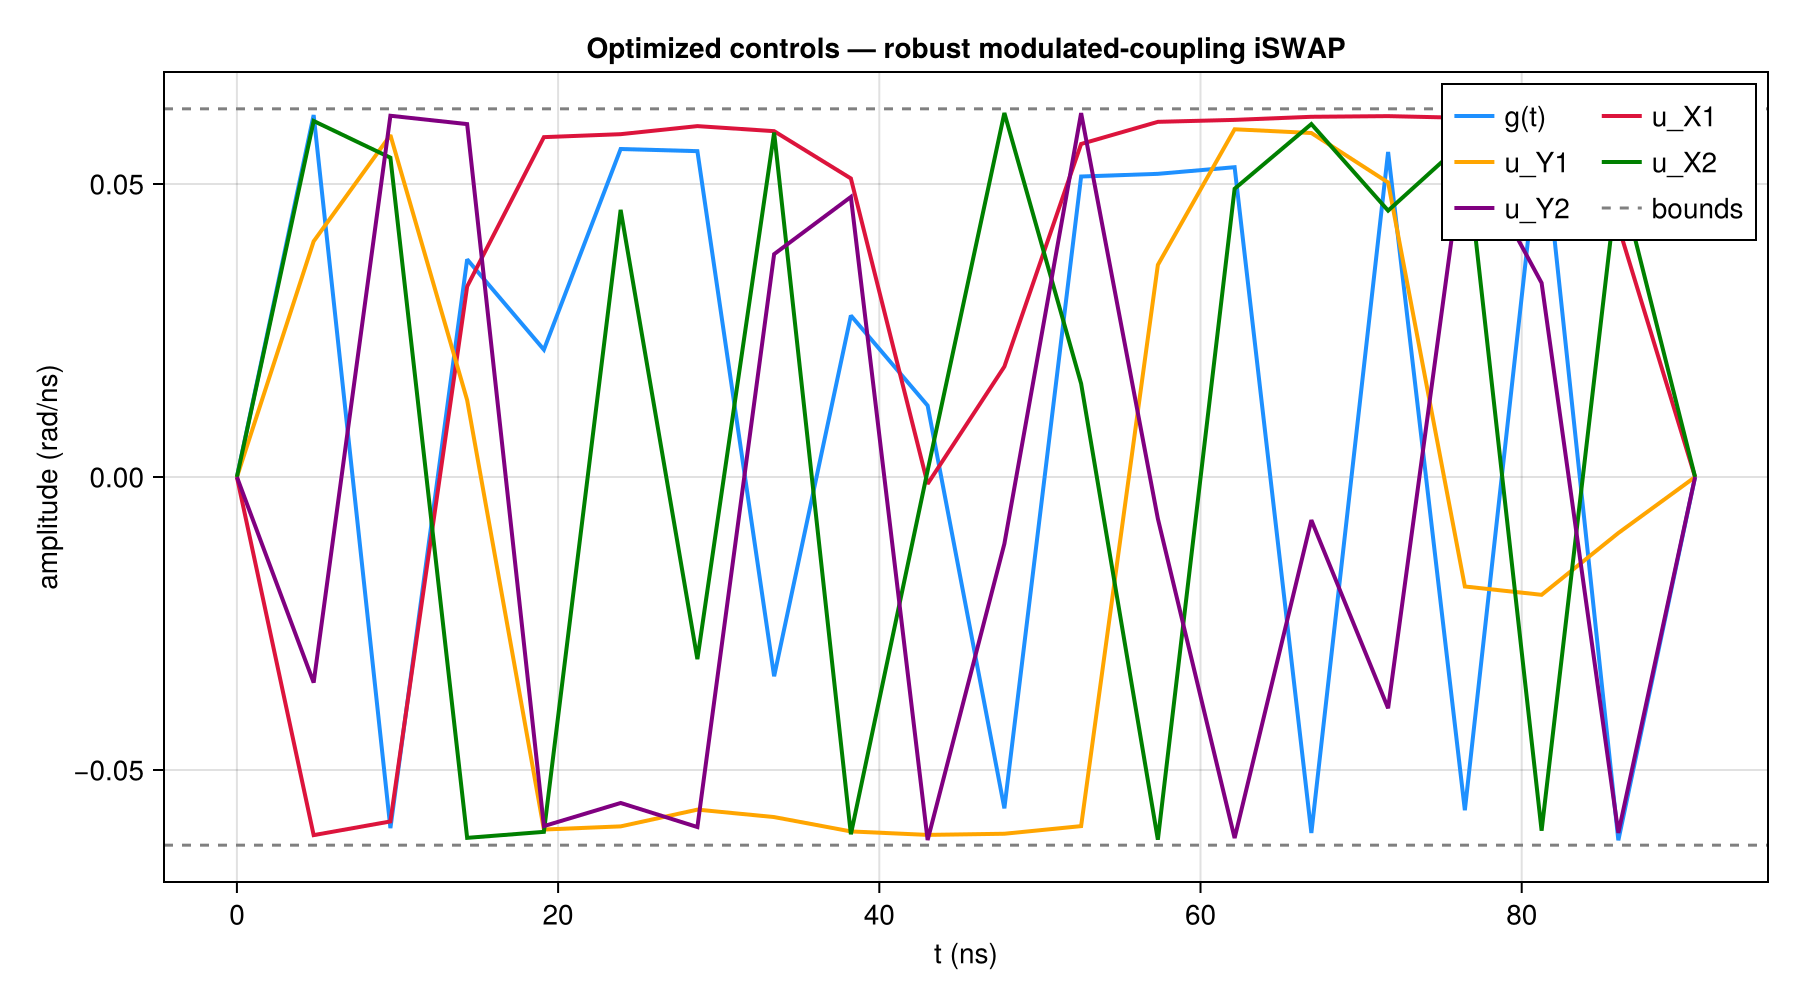

In [12]:
traj = get_trajectory(qcp)
u    = traj[:u]   # (n_drives × N) matrix

# Build time axis from per-step Δt (works for both equal and free timesteps)
Δt_vec = vec(traj[:Δt])          # (N,) vector
ts     = cumsum([0.0; Δt_vec[1:end-1]])   # (N,) cumulative times

println("Gate time: ", round(sum(Δt_vec), digits=2), " ns")
println("Δt range:  ", round.(extrema(Δt_vec), digits=4))

fig = Figure(size = (900, 500))
ax  = Axis(fig[1, 1];
    xlabel = "t (ns)",
    ylabel = "amplitude (rad/ns)",
    title  = "Optimized controls — robust modulated-coupling iSWAP",
)

labels = ["g(t)", "u_X1", "u_Y1", "u_X2", "u_Y2"]
colors = [:dodgerblue, :crimson, :orange, :green, :purple]

for (i, (lbl, col)) in enumerate(zip(labels, colors))
    lines!(ax, ts, vec(u[i, :]); label = lbl, color = col, linewidth = 2)
end

hlines!(ax, [a_bound, -a_bound]; linestyle = :dash, color = :gray, label = "bounds")
axislegend(ax; position = :rt, nbanks = 2)
fig


## Default

Gate time: 104.73 ns
Δt range:  (5.2366, 5.2366)


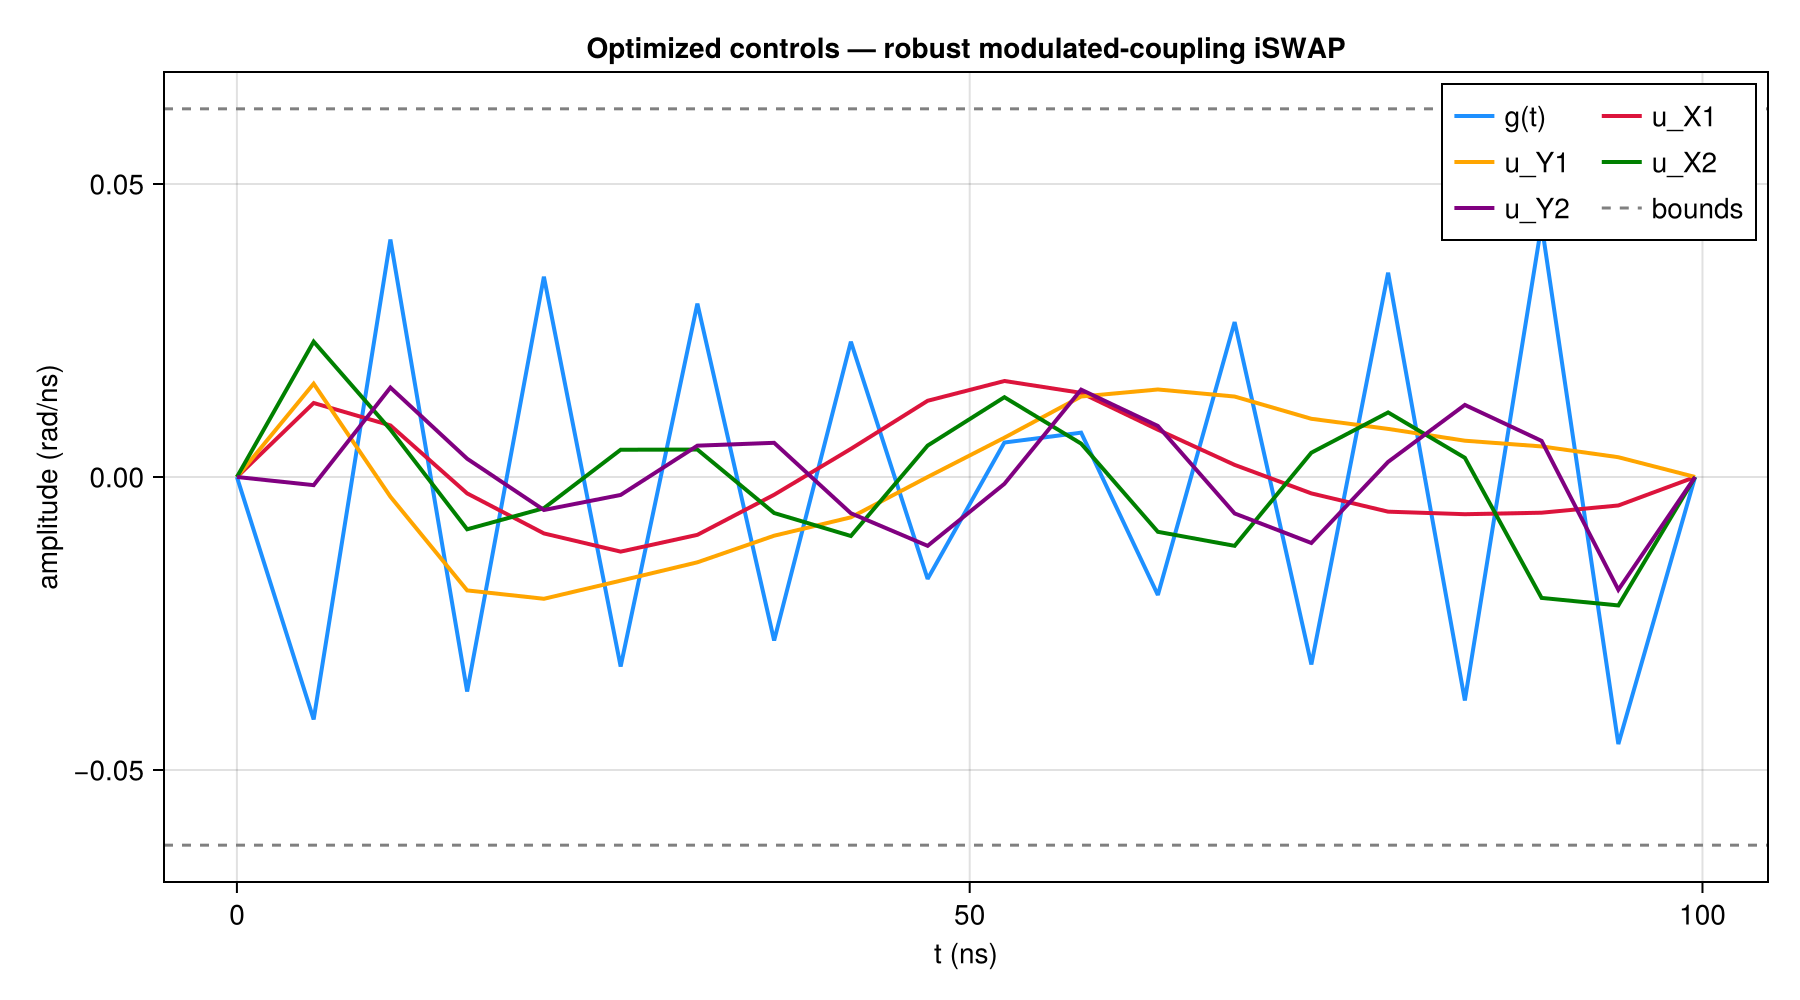

In [ ]:
traj = get_trajectory(qcp_def)
u    = traj[:u]   # (n_drives × N) matrix

# Build time axis from per-step Δt (works for both equal and free timesteps)
Δt_vec = vec(traj[:Δt])          # (N,) vector
ts     = cumsum([0.0; Δt_vec[1:end-1]])   # (N,) cumulative times

println("Gate time: ", round(sum(Δt_vec), digits=2), " ns")
println("Δt range:  ", round.(extrema(Δt_vec), digits=4))

fig = Figure(size = (900, 500))
ax  = Axis(fig[1, 1];
    xlabel = "t (ns)",
    ylabel = "amplitude (rad/ns)",
    title  = "Optimized controls — default modulated-coupling iSWAP",
)

labels = ["g(t)", "u_X1", "u_Y1", "u_X2", "u_Y2"]
colors = [:dodgerblue, :crimson, :orange, :green, :purple]

for (i, (lbl, col)) in enumerate(zip(labels, colors))
    lines!(ax, ts, vec(u[i, :]); label = lbl, color = col, linewidth = 2)
end

hlines!(ax, [a_bound, -a_bound]; linestyle = :dash, color = :gray, label = "bounds")
axislegend(ax; position = :rt, nbanks = 2)
fig


## Fidelity vs. coherent error strength

For each dephasing channel $E \in \{ZI, IZ, ZZ\}$, add $\varepsilon E$ to the Hamiltonian and
re-simulate the optimized pulse using `unitary_rollout_fidelity`.  This traces out the
robustness curve: a flat curve near $\varepsilon=0$ means the pulse is insensitive to that channel.

~153 ODE solves (51 ε values × 3 channels) — takes ~1–2 minutes.

In [21]:
traj     = get_trajectory(qcp)
traj_def = get_trajectory(qcp_def)

# Perturbed system: same H_nonlocal dynamics + static coherent error ε*E
function make_perturbed_sys(ε, E)
    H_p = (u, t) -> H_nonlocal(u, t) + ε * E
    return QuantumSystem(H_p, drive_bounds; time_dependent = true)
end

error_channels = [ZI, IZ, ZZ]
error_labels   = ["ZI", "IZ", "ZZ"]
εs = collect(range(-0.05, 0.05, length = 51))

fidelities = [
    [unitary_rollout_fidelity(traj, make_perturbed_sys(ε, E)) for ε in εs]
    for E in error_channels
]

fidelities_def = [
    [unitary_rollout_fidelity(traj_def, make_perturbed_sys(ε, E)) for ε in εs]
    for E in error_channels
]

@printf("ε=0  robust:  ZI=%.5f  IZ=%.5f  ZZ=%.5f\n",
    fidelities[1][26], fidelities[2][26], fidelities[3][26])
@printf("ε=0  default: ZI=%.5f  IZ=%.5f  ZZ=%.5f\n",
    fidelities_def[1][26], fidelities_def[2][26], fidelities_def[3][26])

ε=0  robust:  ZI=0.99899  IZ=0.99899  ZZ=0.99899
ε=0  default: ZI=0.99999  IZ=0.99999  ZZ=0.99999


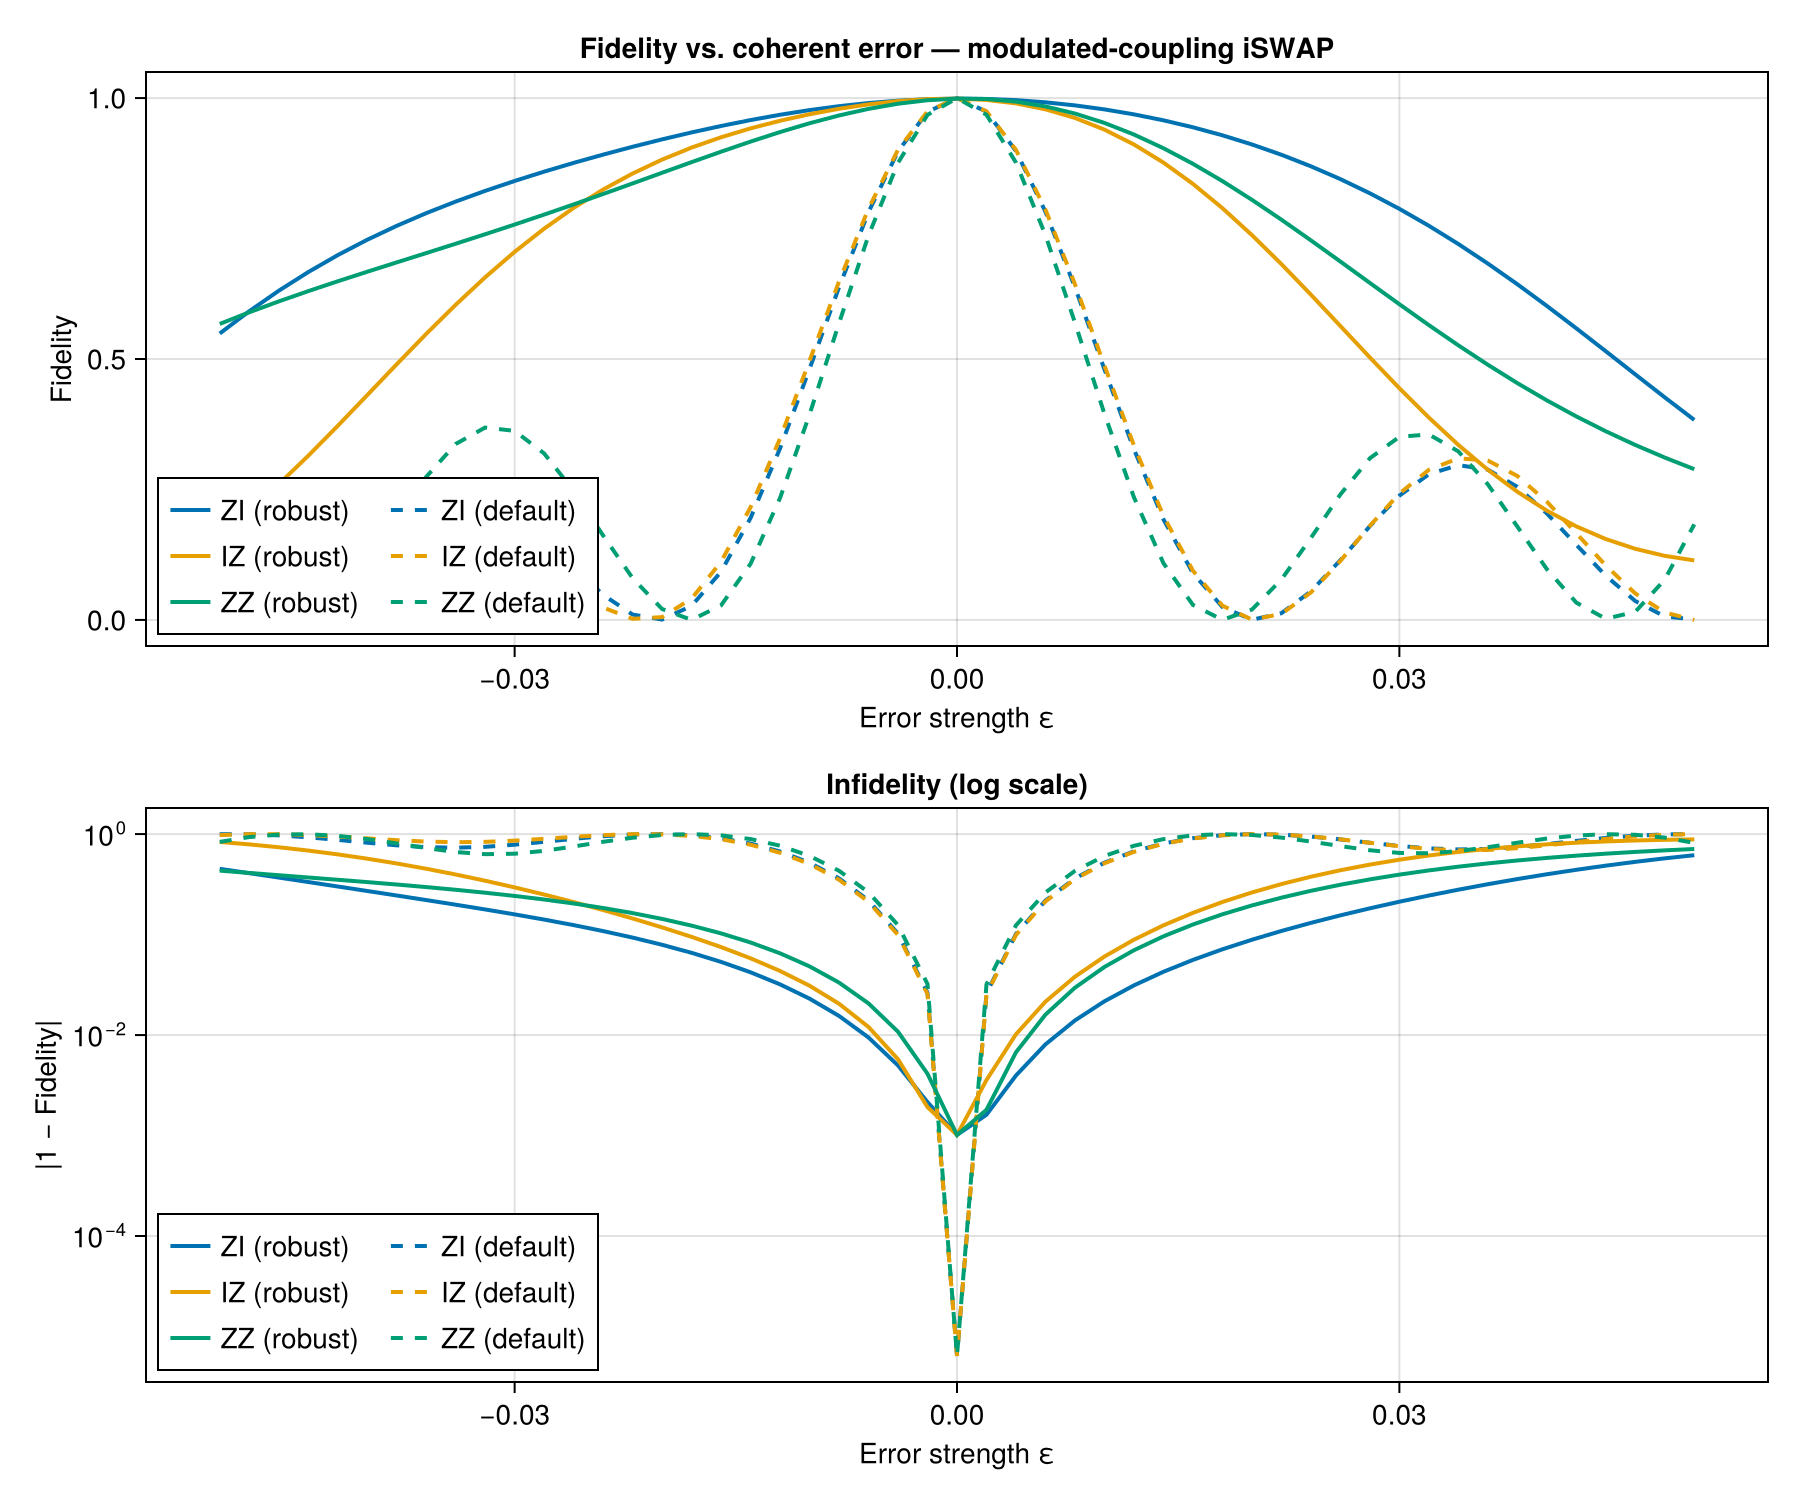

In [23]:
colors = Makie.wong_colors()

fig = Figure(size = (900, 750))

# --- top panel: fidelity (linear) ---
ax1 = Axis(fig[1, 1];
    xlabel = "Error strength ε",
    ylabel = "Fidelity",
    title  = "Fidelity vs. coherent error — modulated-coupling iSWAP",
)

for (i, (lbl, fs, fs_def)) in enumerate(zip(error_labels, fidelities, fidelities_def))
    lines!(ax1, εs, fs;     label = "$lbl (robust)",  color = colors[i], linewidth = 2, linestyle = :solid)
    lines!(ax1, εs, fs_def; label = "$lbl (default)", color = colors[i], linewidth = 2, linestyle = :dash)
end
axislegend(ax1; position = :lb, nbanks = 2)

# --- bottom panel: infidelity (log scale) ---
ax2 = Axis(fig[2, 1];
    xlabel = "Error strength ε",
    ylabel = "|1 − Fidelity|",
    title  = "Infidelity (log scale)",
    yscale = log10,
)

for (i, (lbl, fs, fs_def)) in enumerate(zip(error_labels, fidelities, fidelities_def))
    lines!(ax2, εs, max.(1 .- fs,     1e-16); label = "$lbl (robust)",  color = colors[i], linewidth = 2, linestyle = :solid)
    lines!(ax2, εs, max.(1 .- fs_def, 1e-16); label = "$lbl (default)", color = colors[i], linewidth = 2, linestyle = :dash)
end
axislegend(ax2; position = :lb, nbanks = 2)

fig